# MelCNN MGR Core EDA

Minimal audit of source discovery, final manifest, and live training dataset artifacts.

In [7]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 160)

DEFAULT_SAMPLE_LENGTH_SEC = 15.0


def resolve_project_paths(start: Path) -> tuple[Path, Path]:
    candidates = [start.resolve(), *start.resolve().parents]
    for candidate in candidates:
        if (candidate / 'MelCNN-MGR' / 'settings.json').exists():
            return candidate, candidate / 'MelCNN-MGR'
        if candidate.name == 'MelCNN-MGR' and (candidate / 'settings.json').exists():
            return candidate.parent, candidate
    raise FileNotFoundError('Could not locate workspace root containing MelCNN-MGR/settings.json')


def safe_read_json(path: Path | None) -> dict[str, object] | None:
    if path is None or not path.exists():
        return None
    return json.loads(path.read_text())


def safe_read_parquet(path: Path | None) -> pd.DataFrame | None:
    if path is None or not path.exists():
        return None
    return pd.read_parquet(path)


def first_existing(paths: list[Path | None]) -> Path | None:
    for path in paths:
        if path is not None and path.exists():
            return path
    return None


def load_data_sampling_settings(settings_path: Path) -> dict[str, object]:
    settings_payload = safe_read_json(settings_path)
    config = {} if not isinstance(settings_payload, dict) else settings_payload.get('data_sampling_settings', {})
    return config if isinstance(config, dict) else {}


def positive_float_or_default(value: object, default: float) -> float:
    if isinstance(value, (int, float)) and value > 0:
        return float(value)
    return default


def sample_length_label(sample_length_sec: float) -> str:
    return f'{sample_length_sec:g}s'


def find_latest_matching_dir(base_dirs: list[Path], pattern: str, required_files: list[str], exclude_suffix: str | None = None) -> Path | None:
    matches: list[Path] = []
    for base_dir in base_dirs:
        if not base_dir.exists():
            continue
        for path in base_dir.glob(pattern):
            if not path.is_dir():
                continue
            if exclude_suffix and path.name.endswith(exclude_suffix):
                continue
            if not all((path / filename).exists() for filename in required_files):
                continue
            matches.append(path)
    if not matches:
        return None
    return max(matches, key=lambda path: max((path / filename).stat().st_mtime for filename in required_files))


def plot_bar(series: pd.Series, title: str, xlabel: str = '', ylabel: str = 'count', rotation: int = 45, figsize: tuple[int, int] = (10, 4), color: str = '#4C78A8') -> None:
    data = series.sort_values(ascending=False)
    _, ax = plt.subplots(figsize=figsize)
    data.plot(kind='bar', ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=rotation)
    plt.tight_layout()
    plt.show()


def plot_heatmap(table: pd.DataFrame, title: str, figsize: tuple[int, int] = (10, 6), fmt: str = '.0f') -> None:
    numeric_table = table.apply(pd.to_numeric, errors='coerce')
    if numeric_table.empty:
        print(f'No data available for {title}')
        return
    _, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(numeric_table.values, aspect='auto', cmap='YlGnBu')
    ax.set_xticks(np.arange(numeric_table.shape[1]))
    ax.set_yticks(np.arange(numeric_table.shape[0]))
    ax.set_xticklabels(numeric_table.columns)
    ax.set_yticklabels(numeric_table.index)
    for i in range(numeric_table.shape[0]):
        for j in range(numeric_table.shape[1]):
            value = numeric_table.values[i, j]
            label = '' if pd.isna(value) else format(value, fmt)
            ax.text(j, i, label, ha='center', va='center', color='black', fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


WORKSPACE_ROOT, MELCNN_DIR = resolve_project_paths(Path.cwd())
PROCESSED_DIR = MELCNN_DIR / 'data' / 'processed'
SETTINGS_PATH = MELCNN_DIR / 'settings.json'

sampling_settings = load_data_sampling_settings(SETTINGS_PATH)
sample_length_sec = positive_float_or_default(sampling_settings.get('sample_length_sec'), DEFAULT_SAMPLE_LENGTH_SEC)
sample_length_label = sample_length_label(sample_length_sec)
configured_target_genres = [genre.strip() for genre in sampling_settings.get('target_genres', []) if isinstance(genre, str) and genre.strip()]

source_dataset_paths = {
    'fma': PROCESSED_DIR / 'manifest_fma_datasets.parquet',
    'additional': PROCESSED_DIR / 'manifest_additional_datasets.parquet',
}
final_samples_path = PROCESSED_DIR / 'manifest_final_samples.parquet'
final_config_path = PROCESSED_DIR / 'manifest_final_samples.config.json'

all_datasets_df = pd.concat([frame.assign(_source_manifest=name) for name, frame in {k: safe_read_parquet(v) for k, v in source_dataset_paths.items()}.items() if frame is not None], ignore_index=True)
final_samples_df = pd.read_parquet(final_samples_path)
final_config = safe_read_json(final_config_path)

cache_roots = [Path('/home/hsnguyen/model-training-data-cache'), MELCNN_DIR / 'cache']
logmel_dataset_dir = first_existing([
    cache_roots[0] / f'logmel_dataset_{sample_length_label}',
    cache_roots[1] / f'logmel_dataset_{sample_length_label}',
    find_latest_matching_dir(cache_roots, 'logmel_dataset_*', ['logmel_config.json', 'logmel_manifest_all.parquet'], exclude_suffix='_tfrecord'),
])
tfrecord_dataset_dir = first_existing([
    cache_roots[0] / f'logmel_dataset_{sample_length_label}_tfrecord',
    cache_roots[1] / f'logmel_dataset_{sample_length_label}_tfrecord',
    find_latest_matching_dir(cache_roots, 'logmel_dataset_*_tfrecord', ['tfrecord_config.json', 'tfrecord_manifest_all.parquet']),
])

logmel_all_df = safe_read_parquet(None if logmel_dataset_dir is None else logmel_dataset_dir / 'logmel_manifest_all.parquet')
tfrecord_all_df = safe_read_parquet(None if tfrecord_dataset_dir is None else tfrecord_dataset_dir / 'tfrecord_manifest_all.parquet')
tfrecord_config = safe_read_json(None if tfrecord_dataset_dir is None else tfrecord_dataset_dir / 'tfrecord_config.json')

print(f'Workspace root: {WORKSPACE_ROOT}')
print(f'Processed dir : {PROCESSED_DIR}')
print(f'Log-mel dir   : {logmel_dataset_dir}')
print(f'TFRecord dir  : {tfrecord_dataset_dir}')

Workspace root: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1
Processed dir : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed
Log-mel dir   : /home/hsnguyen/model-training-data-cache/logmel_dataset_15s
TFRecord dir  : /home/hsnguyen/model-training-data-cache/logmel_dataset_15s_tfrecord


In [8]:
core_snapshot = pd.DataFrame([
    {'metric': 'configured_target_genres', 'value': ', '.join(configured_target_genres)},
    {'metric': 'configured_target_genre_count', 'value': len(configured_target_genres)},
    {'metric': 'sample_length_sec', 'value': sample_length_sec},
    {'metric': 'file_level_rows', 'value': len(all_datasets_df)},
    {'metric': 'final_manifest_rows', 'value': len(final_samples_df)},
    {'metric': 'logmel_rows', 'value': 0 if logmel_all_df is None else len(logmel_all_df)},
    {'metric': 'tfrecord_rows', 'value': 0 if tfrecord_all_df is None else len(tfrecord_all_df)},
    {'metric': 'tfrecord_n_classes', 'value': None if tfrecord_all_df is None or 'label_int' not in tfrecord_all_df.columns else int(tfrecord_all_df['label_int'].nunique())},
])
display(core_snapshot)

,metric,value
0,configured_target_genres,"Hip-Hop, Pop, Rock, Metal, Classical, Jazz, Country, Blues, Bolero, Speech"
1,configured_target_genre_count,10
2,sample_length_sec,15.0
3,file_level_rows,25217
4,final_manifest_rows,24973
5,logmel_rows,22671
6,tfrecord_rows,22037
7,tfrecord_n_classes,10


## File-Level Core

,metric,value
0,unique_sources,4.0
1,unique_genres,11.0
2,rows_with_duration,25096.0
3,total_discovered_duration_hours,212.0


,source,rows
0,fma-medium,14059
1,my-collection,7853
2,mtg-jamendo,2605
3,gtzan,700


,genre_top,rows
0,Rock,7013
1,Electronic,5314
2,Hip-Hop,1984
3,Classical,1638
4,Jazz,1524
5,Pop,1485
6,Bolero,1469
7,Blues,1447
8,Speech,1218
9,Country,1120


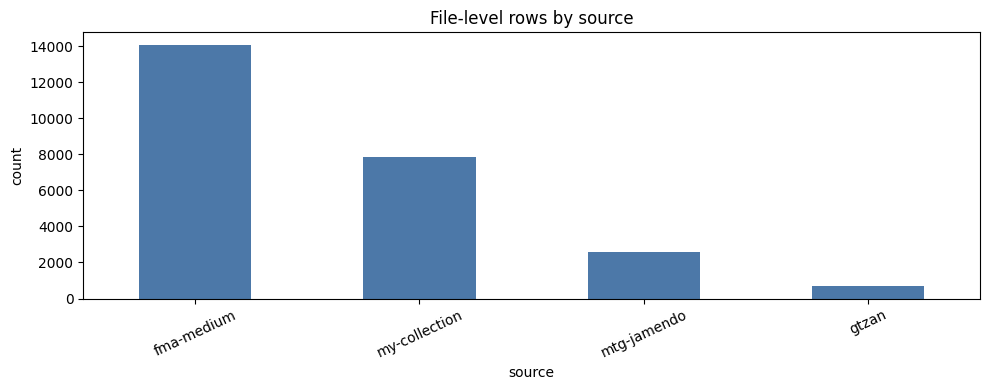

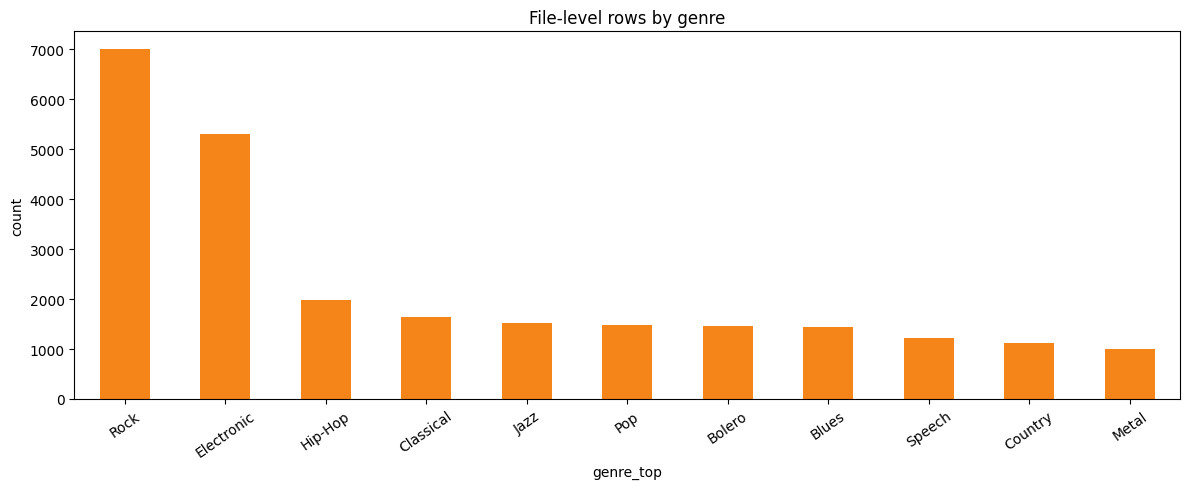

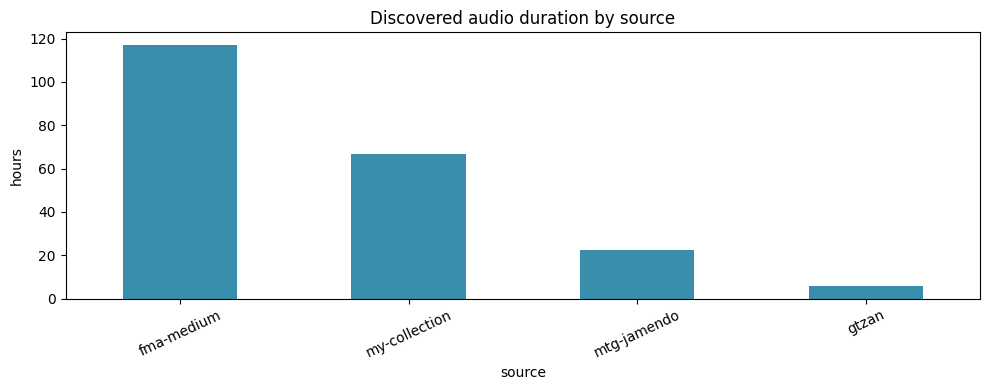

In [9]:
display(Markdown('## File-Level Core'))

source_counts = all_datasets_df['source'].value_counts()
genre_counts = all_datasets_df['genre_top'].value_counts()
duration_df = all_datasets_df.copy()
duration_df['duration_for_aggregation_s'] = pd.to_numeric(duration_df['actual_duration_s'], errors='coerce').fillna(pd.to_numeric(duration_df['duration_s'], errors='coerce'))
duration_df = duration_df[duration_df['duration_for_aggregation_s'].notna() & (duration_df['duration_for_aggregation_s'] > 0)].copy()
duration_by_source = (duration_df.groupby('source')['duration_for_aggregation_s'].sum() / 3600.0).sort_values(ascending=False)

file_level_metrics = pd.DataFrame([
    {'metric': 'unique_sources', 'value': int(all_datasets_df['source'].nunique())},
    {'metric': 'unique_genres', 'value': int(all_datasets_df['genre_top'].nunique())},
    {'metric': 'rows_with_duration', 'value': len(duration_df)},
    {'metric': 'total_discovered_duration_hours', 'value': round(duration_by_source.sum(), 2)},
])
display(file_level_metrics)
display(source_counts.rename_axis('source').reset_index(name='rows'))
display(genre_counts.rename_axis('genre_top').reset_index(name='rows').head(15))
plot_bar(source_counts, title='File-level rows by source', xlabel='source', rotation=25, color='#4C78A8')
plot_bar(genre_counts.head(15), title='File-level rows by genre', xlabel='genre_top', rotation=35, figsize=(12, 5), color='#F58518')
plot_bar(duration_by_source, title='Discovered audio duration by source', xlabel='source', ylabel='hours', rotation=25, color='#388EAB')

## Final Manifest Core

,metric,value
0,final_target_rows,22671.00
1,excluded_off_target_rows,2302.00
2,target_genres_in_final,10.00
3,final_effective_hours,94.46


,final_split,rows
0,training,15864
1,validation,3402
2,test,3405


,genre_top,rows
0,Classical,2304
1,Jazz,2304
2,Rock,2303
3,Blues,2302
4,Bolero,2302
5,Hip-Hop,2302
6,Pop,2302
7,Speech,2302
8,Country,2240
9,Metal,2010


,genre_top,excluded_rows
0,Electronic,2302


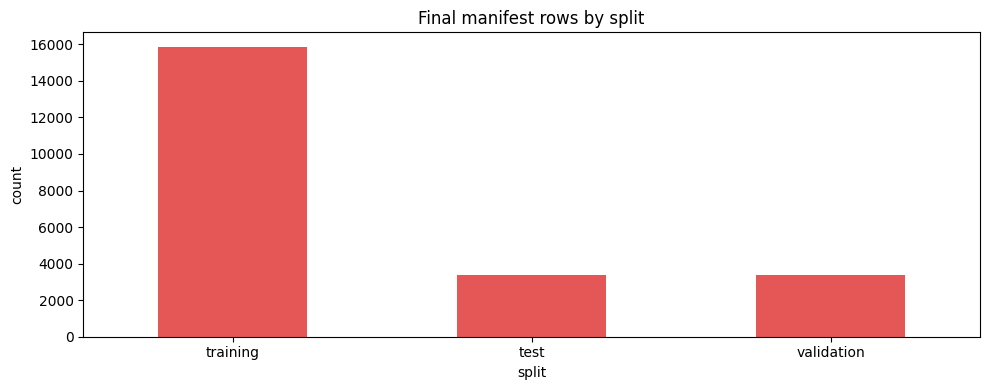

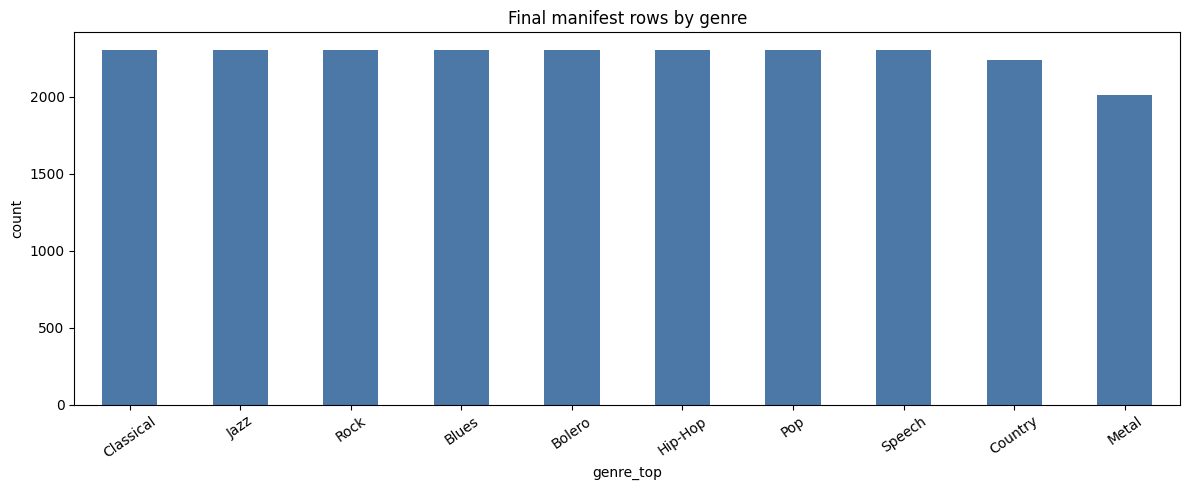

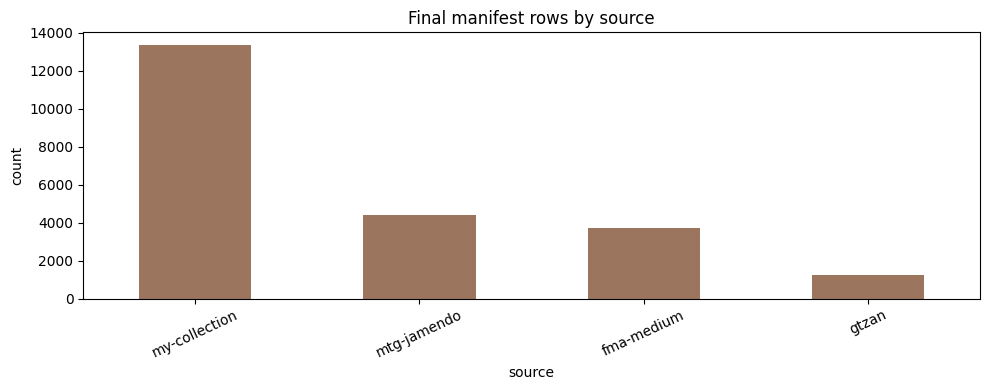

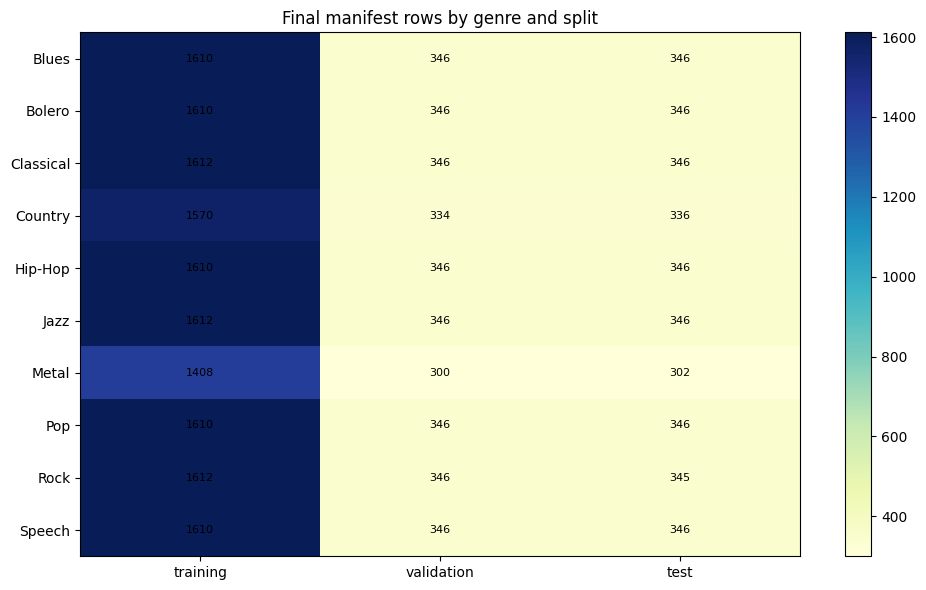

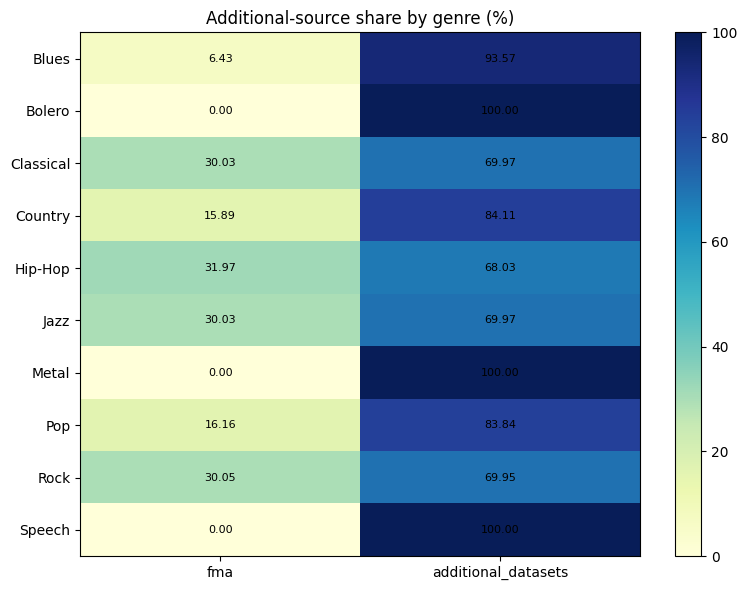

In [10]:
display(Markdown('## Final Manifest Core'))

target_mask = final_samples_df['genre_top'].isin(configured_target_genres) if configured_target_genres else pd.Series(True, index=final_samples_df.index)
final_target_df = final_samples_df[target_mask].copy()
final_excluded_df = final_samples_df[~target_mask].copy()
final_genre_counts = final_target_df['genre_top'].value_counts()
final_split_counts = final_target_df['final_split'].value_counts().reindex(['training', 'validation', 'test'], fill_value=0)
final_source_counts = final_target_df['source'].value_counts()
genre_split_counts = pd.crosstab(final_target_df['genre_top'], final_target_df['final_split']).reindex(columns=['training', 'validation', 'test'], fill_value=0)

source_family_df = final_target_df.copy()
source_family_df['source_family'] = np.where(source_family_df['source'].astype(str).str.casefold().str.startswith('fma'), 'fma', 'additional_datasets')
source_family_pct = pd.crosstab(source_family_df['genre_top'], source_family_df['source_family']).reindex(columns=['fma', 'additional_datasets'], fill_value=0)
source_family_pct = source_family_pct.div(source_family_pct.sum(axis=1), axis=0).mul(100).round(2)

final_core_metrics = pd.DataFrame([
    {'metric': 'final_target_rows', 'value': len(final_target_df)},
    {'metric': 'excluded_off_target_rows', 'value': len(final_excluded_df)},
    {'metric': 'target_genres_in_final', 'value': int(final_target_df['genre_top'].nunique())},
    {'metric': 'final_effective_hours', 'value': round(len(final_target_df) * sample_length_sec / 3600.0, 2)},
])
display(final_core_metrics)
display(final_split_counts.rename_axis('final_split').reset_index(name='rows'))
display(final_genre_counts.rename_axis('genre_top').reset_index(name='rows'))
if not final_excluded_df.empty:
    display(final_excluded_df['genre_top'].value_counts().rename_axis('genre_top').reset_index(name='excluded_rows'))
plot_bar(final_split_counts, title='Final manifest rows by split', xlabel='split', rotation=0, color='#E45756')
plot_bar(final_genre_counts, title='Final manifest rows by genre', xlabel='genre_top', rotation=35, figsize=(12, 5), color='#4C78A8')
plot_bar(final_source_counts, title='Final manifest rows by source', xlabel='source', rotation=25, color='#9C755F')
plot_heatmap(genre_split_counts.astype(float), title='Final manifest rows by genre and split', figsize=(10, 6), fmt='.0f')
plot_heatmap(source_family_pct.astype(float), title='Additional-source share by genre (%)', figsize=(8, 6), fmt='.2f')

## Core Statistical Metrics

### File-Level KPI Summary

,metric,value
0,unique_source_files_in_final_target_manifest,11336.00
1,selected_rows_in_final_target_manifest,22671.00
2,mean_selected_segments_per_file,2.00
3,min_selected_segments_per_file,1.00
4,max_selected_segments_per_file,2.00
5,mean_source_file_duration_sec,30.78
6,min_source_file_duration_sec,24.06
7,max_source_file_duration_sec,31.00


### File-Level Distribution Summary

,metric_set,count,mean,median,mode,std,variance,min,max,skewness,kurtosis
0,selected_segments_per_file,11336,2.00,2.0,2.0,0.01,0.00,1.00,2.0,-106.47,11336.00
1,source_file_duration_sec,11336,30.78,31.0,31.0,0.41,0.17,24.06,31.0,-1.71,5.89
2,unique_files_per_genre,10,1133.60,1151.0,1151.0,46.25,2139.16,1005.00,1152.0,-2.93,8.75


Each row in the file-level summary corresponds to one unique source file after deduplicating segment rows using the source artifact id derived from `sample_id`.

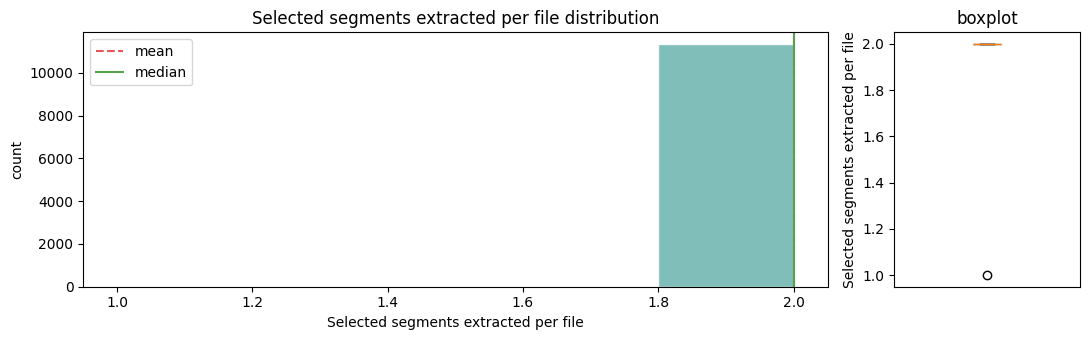

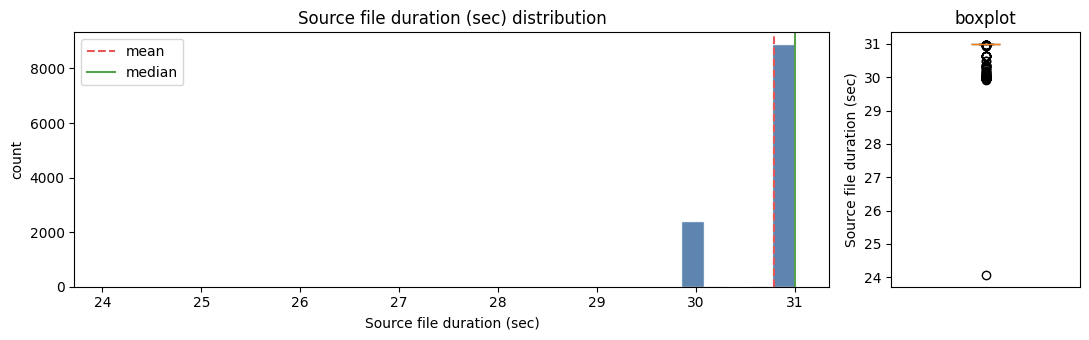

In [11]:
display(Markdown('## Core Statistical Metrics'))


def prepare_numeric_series(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors='coerce').dropna()
    return numeric[numeric.notna()]


def summarize_numeric_distribution(name: str, series: pd.Series) -> dict[str, object]:
    numeric = prepare_numeric_series(series)
    if numeric.empty:
        return {
            'metric_set': name,
            'count': 0,
            'mean': np.nan,
            'median': np.nan,
            'mode': np.nan,
            'std': np.nan,
            'variance': np.nan,
            'min': np.nan,
            'max': np.nan,
            'skewness': np.nan,
            'kurtosis': np.nan,
        }

    mode_series = numeric.mode(dropna=True)
    return {
        'metric_set': name,
        'count': int(numeric.count()),
        'mean': round(float(numeric.mean()), 2),
        'median': round(float(numeric.median()), 2),
        'mode': round(float(mode_series.iloc[0]), 2) if not mode_series.empty else np.nan,
        'std': round(float(numeric.std(ddof=1)), 2) if len(numeric) > 1 else 0.0,
        'variance': round(float(numeric.var(ddof=1)), 2) if len(numeric) > 1 else 0.0,
        'min': round(float(numeric.min()), 2),
        'max': round(float(numeric.max()), 2),
        'skewness': round(float(numeric.skew()), 2) if len(numeric) > 2 else np.nan,
        'kurtosis': round(float(numeric.kurt()), 2) if len(numeric) > 3 else np.nan,
    }


def plot_distribution_pair(series: pd.Series, title: str, bins: int = 30, color: str = '#4C78A8') -> None:
    numeric = prepare_numeric_series(series)
    if numeric.empty:
        print(f'No data available for {title}')
        return

    _, axes = plt.subplots(1, 2, figsize=(11, 3.5), gridspec_kw={'width_ratios': [4, 1]})
    axes[0].hist(numeric, bins=bins, color=color, alpha=0.9, edgecolor='white')
    axes[0].axvline(numeric.mean(), color='#E45756', linestyle='--', linewidth=1.5, label='mean')
    axes[0].axvline(numeric.median(), color='#54A24B', linestyle='-', linewidth=1.5, label='median')
    axes[0].set_title(f'{title} distribution')
    axes[0].set_xlabel(title)
    axes[0].set_ylabel('count')
    axes[0].legend()

    axes[1].boxplot(numeric, vert=True, patch_artist=True, boxprops={'facecolor': color, 'alpha': 0.7})
    axes[1].set_title('boxplot')
    axes[1].set_xticks([])
    axes[1].set_ylabel(title)

    plt.tight_layout()
    plt.show()


if 'sample_id' in final_target_df.columns:
    file_level_df = final_target_df.copy()
    file_level_df['artifact_id'] = file_level_df['sample_id'].astype(str).str.replace(r':seg\d+$', '', regex=True)
else:
    file_level_df = final_target_df.copy()
    file_level_df['artifact_id'] = file_level_df['filepath'].astype(str) if 'filepath' in file_level_df.columns else np.arange(len(file_level_df)).astype(str)

if 'actual_duration_s' in file_level_df.columns and 'duration_s' in file_level_df.columns:
    file_level_df['file_duration_s'] = pd.to_numeric(file_level_df['actual_duration_s'], errors='coerce').fillna(
        pd.to_numeric(file_level_df['duration_s'], errors='coerce')
    )
elif 'duration_s' in file_level_df.columns:
    file_level_df['file_duration_s'] = pd.to_numeric(file_level_df['duration_s'], errors='coerce')
else:
    file_level_df['file_duration_s'] = np.nan

per_file_summary = file_level_df.groupby('artifact_id').agg(
    source=('source', 'first') if 'source' in file_level_df.columns else ('artifact_id', 'first'),
    genre_top=('genre_top', 'first') if 'genre_top' in file_level_df.columns else ('artifact_id', 'first'),
    filepath=('filepath', 'first') if 'filepath' in file_level_df.columns else ('artifact_id', 'first'),
    file_duration_s=('file_duration_s', 'first'),
    selected_segments=('artifact_id', 'size'),
).reset_index()

file_duration_unique_series = prepare_numeric_series(per_file_summary['file_duration_s'])
segments_per_file_series = prepare_numeric_series(per_file_summary['selected_segments'])
files_per_genre_series = prepare_numeric_series(per_file_summary['genre_top'].value_counts()) if 'genre_top' in per_file_summary.columns else pd.Series(dtype=float)

file_level_kpis = pd.DataFrame([
    {'metric': 'unique_source_files_in_final_target_manifest', 'value': int(per_file_summary['artifact_id'].nunique())},
    {'metric': 'selected_rows_in_final_target_manifest', 'value': int(len(final_target_df))},
    {'metric': 'mean_selected_segments_per_file', 'value': round(float(segments_per_file_series.mean()), 2) if not segments_per_file_series.empty else np.nan},
    {'metric': 'min_selected_segments_per_file', 'value': int(segments_per_file_series.min()) if not segments_per_file_series.empty else np.nan},
    {'metric': 'max_selected_segments_per_file', 'value': int(segments_per_file_series.max()) if not segments_per_file_series.empty else np.nan},
    {'metric': 'mean_source_file_duration_sec', 'value': round(float(file_duration_unique_series.mean()), 2) if not file_duration_unique_series.empty else np.nan},
    {'metric': 'min_source_file_duration_sec', 'value': round(float(file_duration_unique_series.min()), 2) if not file_duration_unique_series.empty else np.nan},
    {'metric': 'max_source_file_duration_sec', 'value': round(float(file_duration_unique_series.max()), 2) if not file_duration_unique_series.empty else np.nan},
])

core_statistical_metrics = pd.DataFrame([
    summarize_numeric_distribution('selected_segments_per_file', segments_per_file_series),
    summarize_numeric_distribution('source_file_duration_sec', file_duration_unique_series),
    summarize_numeric_distribution('unique_files_per_genre', files_per_genre_series),
])

display(Markdown('### File-Level KPI Summary'))
display(file_level_kpis)
display(Markdown('### File-Level Distribution Summary'))
display(core_statistical_metrics)
display(Markdown('Each row in the file-level summary corresponds to one unique source file after deduplicating segment rows using the source artifact id derived from `sample_id`.'))

plot_distribution_pair(segments_per_file_series, title='Selected segments extracted per file', bins=min(30, max(5, int(segments_per_file_series.nunique()))) if not segments_per_file_series.empty else 10, color='#72B7B2')
plot_distribution_pair(file_duration_unique_series, title='Source file duration (sec)', bins=30, color='#4C78A8')

## Segment-Level Distribution Summary

### Segment-Level KPI Summary

,metric,value
0,selected_segments_in_final_target_manifest,22671.0
1,unique_segment_genres,10.0
2,mean_segment_length_sec,15.0
3,min_segment_length_sec,15.0
4,max_segment_length_sec,15.0
5,mean_segment_start_sec,7.5
6,min_segment_start_sec,0.0
7,max_segment_start_sec,15.0


### Segment-Level Distribution Summary

,metric_set,count,mean,median,mode,std,variance,min,max,skewness,kurtosis
0,segment_length_sec,22671,15.00,15.0,15.0,0.00,0.00,15.00,15.0,0.00,0.00
1,segment_start_sec,22671,7.50,0.0,0.0,7.50,56.25,0.00,15.0,0.00,-2.00
2,segment_end_sec,22671,22.50,15.0,15.0,7.50,56.25,15.00,30.0,0.00,-2.00
3,segment_index,22671,0.50,0.0,0.0,0.50,0.25,0.00,1.0,0.00,-2.00
4,source_file_duration_attached_to_segments_sec,22671,30.78,31.0,31.0,0.41,0.17,24.06,31.0,-1.55,2.98
5,segments_per_genre,10,2267.10,2302.0,2302.0,92.46,8548.54,2010.00,2304.0,-2.93,8.75


Each row in the segment-level summary corresponds to one selected segment row in the final target manifest.

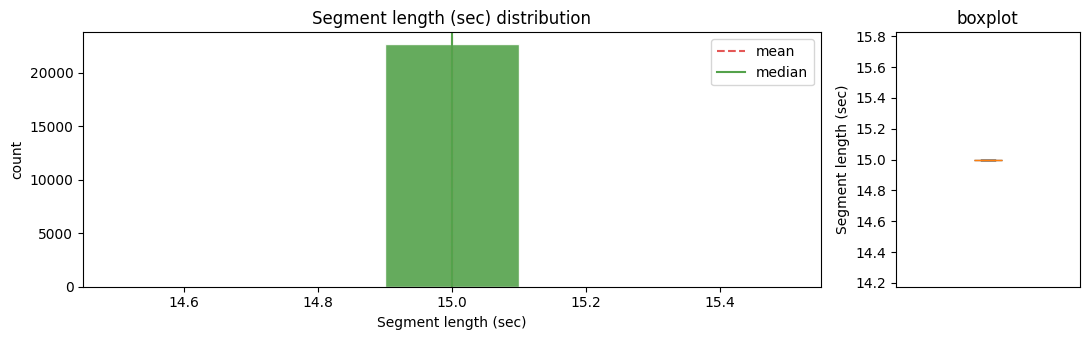

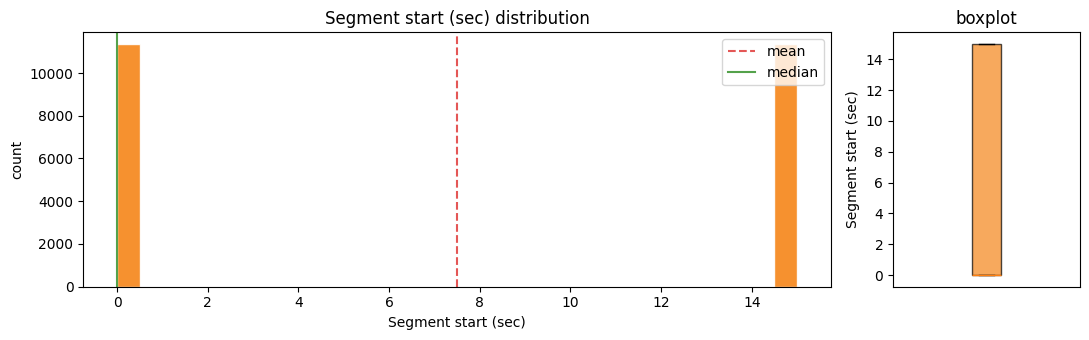

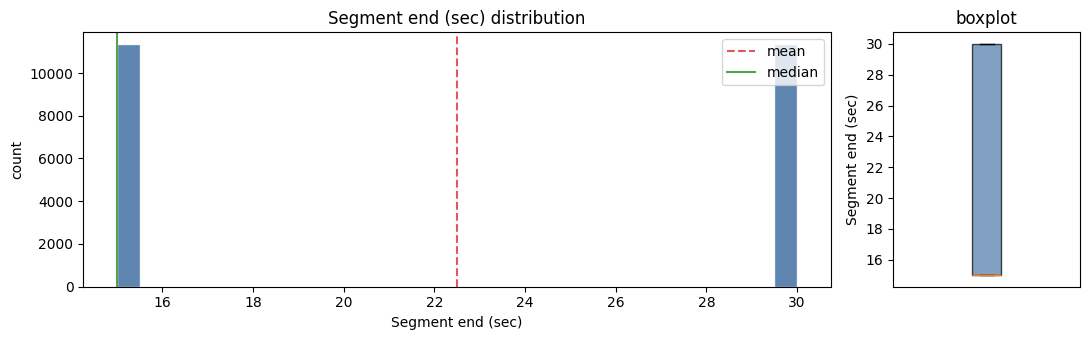

In [12]:
display(Markdown('## Segment-Level Distribution Summary'))

segment_level_df = final_target_df.copy()

if 'actual_duration_s' in segment_level_df.columns and 'duration_s' in segment_level_df.columns:
    segment_level_df['source_file_duration_s'] = pd.to_numeric(segment_level_df['actual_duration_s'], errors='coerce').fillna(
        pd.to_numeric(segment_level_df['duration_s'], errors='coerce')
    )
elif 'duration_s' in segment_level_df.columns:
    segment_level_df['source_file_duration_s'] = pd.to_numeric(segment_level_df['duration_s'], errors='coerce')
else:
    segment_level_df['source_file_duration_s'] = np.nan

segment_start_series = prepare_numeric_series(segment_level_df['segment_start_sec']) if 'segment_start_sec' in segment_level_df.columns else pd.Series(dtype=float)
segment_end_series = prepare_numeric_series(segment_level_df['segment_end_sec']) if 'segment_end_sec' in segment_level_df.columns else pd.Series(dtype=float)
segment_index_series = prepare_numeric_series(segment_level_df['segment_index']) if 'segment_index' in segment_level_df.columns else pd.Series(dtype=float)
segment_length_series = prepare_numeric_series(
    segment_level_df['sample_length_sec'] if 'sample_length_sec' in segment_level_df.columns else pd.Series(dtype=float)
 )
segment_source_duration_series = prepare_numeric_series(segment_level_df['source_file_duration_s'])
segments_per_genre_series = prepare_numeric_series(segment_level_df['genre_top'].value_counts()) if 'genre_top' in segment_level_df.columns else pd.Series(dtype=float)

segment_level_kpis = pd.DataFrame([
    {'metric': 'selected_segments_in_final_target_manifest', 'value': int(len(segment_level_df))},
    {'metric': 'unique_segment_genres', 'value': int(segment_level_df['genre_top'].nunique()) if 'genre_top' in segment_level_df.columns else np.nan},
    {'metric': 'mean_segment_length_sec', 'value': round(float(segment_length_series.mean()), 2) if not segment_length_series.empty else np.nan},
    {'metric': 'min_segment_length_sec', 'value': round(float(segment_length_series.min()), 2) if not segment_length_series.empty else np.nan},
    {'metric': 'max_segment_length_sec', 'value': round(float(segment_length_series.max()), 2) if not segment_length_series.empty else np.nan},
    {'metric': 'mean_segment_start_sec', 'value': round(float(segment_start_series.mean()), 2) if not segment_start_series.empty else np.nan},
    {'metric': 'min_segment_start_sec', 'value': round(float(segment_start_series.min()), 2) if not segment_start_series.empty else np.nan},
    {'metric': 'max_segment_start_sec', 'value': round(float(segment_start_series.max()), 2) if not segment_start_series.empty else np.nan},
])

segment_distribution_summary = pd.DataFrame([
    summarize_numeric_distribution('segment_length_sec', segment_length_series),
    summarize_numeric_distribution('segment_start_sec', segment_start_series),
    summarize_numeric_distribution('segment_end_sec', segment_end_series),
    summarize_numeric_distribution('segment_index', segment_index_series),
    summarize_numeric_distribution('source_file_duration_attached_to_segments_sec', segment_source_duration_series),
    summarize_numeric_distribution('segments_per_genre', segments_per_genre_series),
])

display(Markdown('### Segment-Level KPI Summary'))
display(segment_level_kpis)
display(Markdown('### Segment-Level Distribution Summary'))
display(segment_distribution_summary)
display(Markdown('Each row in the segment-level summary corresponds to one selected segment row in the final target manifest.'))

plot_distribution_pair(segment_length_series, title='Segment length (sec)', bins=min(20, max(5, int(segment_length_series.nunique()))) if not segment_length_series.empty else 10, color='#54A24B')
plot_distribution_pair(segment_start_series, title='Segment start (sec)', bins=30, color='#F58518')
plot_distribution_pair(segment_end_series, title='Segment end (sec)', bins=30, color='#4C78A8')

## Final Training Dataset

,metric,value
0,total_rows,22037
1,n_classes,10
2,genres,"Blues, Bolero, Classical, Country, Hip-Hop, Jazz, Metal, Pop, Rock, Speech"
3,sample_length_sec,15.0


,label_int,genre_top
0,0,Blues
1,1,Bolero
2,2,Classical
3,3,Country
4,4,Hip-Hop
5,5,Jazz
6,6,Metal
7,7,Pop
8,8,Rock
9,9,Speech


,split,rows
0,train,15406
1,val,3309
2,test,3322


,genre_top,rows
0,Blues,2262
1,Jazz,2248
2,Bolero,2240
3,Rock,2240
4,Hip-Hop,2238
5,Classical,2235
6,Pop,2228
7,Speech,2225
8,Country,2175
9,Metal,1946


split_dir,train,val,test
genre_top,,,
Blues,1582,339,341
Bolero,1573,334,333
Classical,1558,337,340
Country,1520,329,326
Hip-Hop,1564,335,339
Jazz,1572,337,339
Metal,1363,288,295
Pop,1558,334,336
Rock,1573,333,334


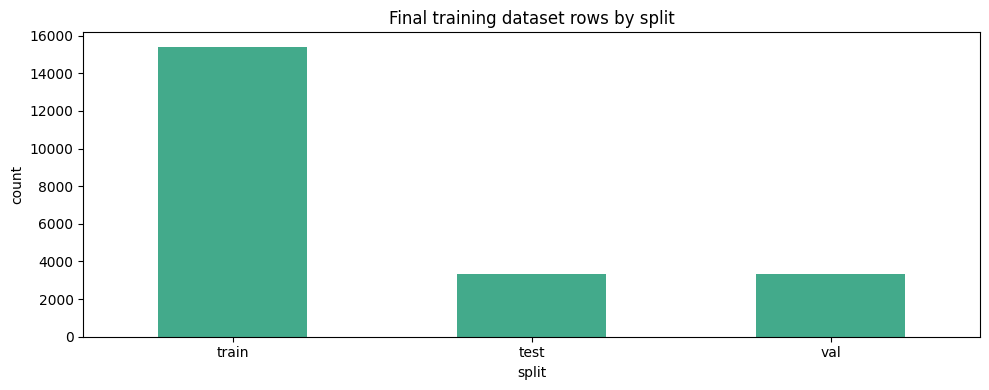

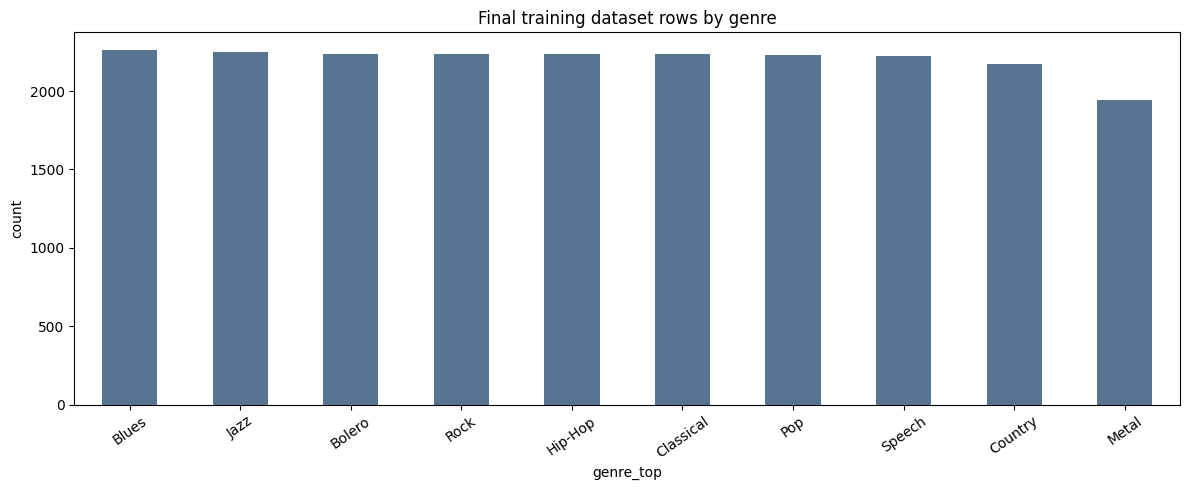

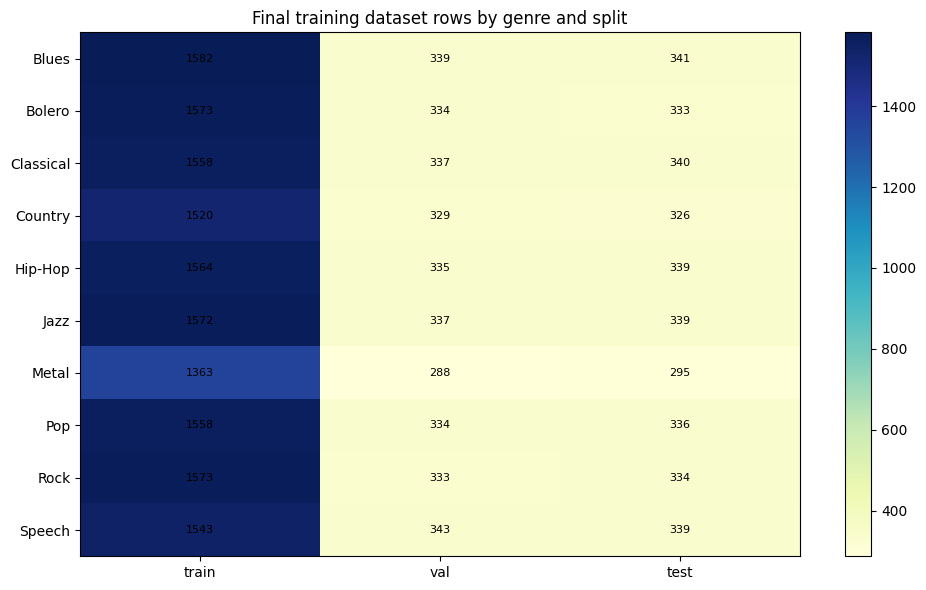

In [13]:
display(Markdown('## Final Training Dataset'))

training_df = tfrecord_all_df.copy() if tfrecord_all_df is not None else None
if training_df is None or training_df.empty:
    print('No live TFRecord manifest found.')
else:
    class_mapping = training_df[['label_int', 'genre_top']].drop_duplicates().sort_values(['label_int', 'genre_top']).reset_index(drop=True) if {'label_int', 'genre_top'}.issubset(training_df.columns) else pd.DataFrame(columns=['label_int', 'genre_top'])
    split_counts = training_df['split_dir'].astype(str).value_counts().reindex(['train', 'val', 'test'], fill_value=0)
    genre_counts = training_df['genre_top'].astype(str).value_counts()
    genre_split_counts = pd.crosstab(training_df['genre_top'].astype(str), training_df['split_dir'].astype(str)).reindex(columns=['train', 'val', 'test'], fill_value=0)

    training_metrics = pd.DataFrame([
        {'metric': 'total_rows', 'value': len(training_df)},
        {'metric': 'n_classes', 'value': 0 if class_mapping.empty else int(class_mapping['genre_top'].nunique())},
        {'metric': 'genres', 'value': ', '.join(class_mapping['genre_top'].tolist())},
        {'metric': 'sample_length_sec', 'value': float(training_df['sample_length_sec'].dropna().iloc[0]) if 'sample_length_sec' in training_df.columns and training_df['sample_length_sec'].notna().any() else None},
])
    display(training_metrics)
    display(class_mapping)
    display(split_counts.rename_axis('split').reset_index(name='rows'))
    display(genre_counts.rename_axis('genre_top').reset_index(name='rows'))
    display(genre_split_counts)
    plot_bar(split_counts, title='Final training dataset rows by split', xlabel='split', rotation=0, color='#43AA8B')
    plot_bar(genre_counts, title='Final training dataset rows by genre', xlabel='genre_top', rotation=35, figsize=(12, 5), color='#577590')
    plot_heatmap(genre_split_counts.astype(float), title='Final training dataset rows by genre and split', figsize=(10, 6), fmt='.0f')